===== DATASET POLICE =====

Overall Arrest Rate:
0.09025408486936048


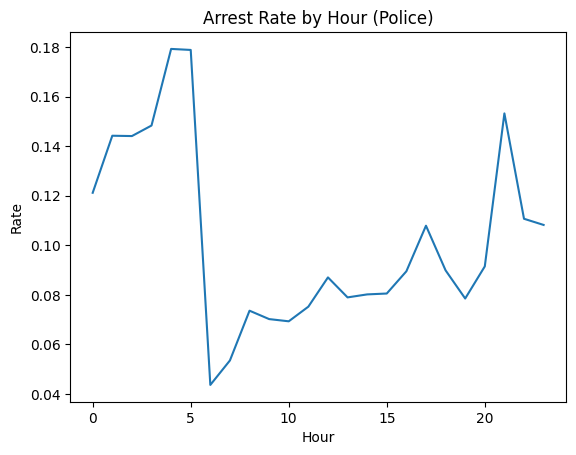

/tmp/ipykernel_7931/2723188583.py:41: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  annual_drug_rate = ri['drugs_related_stop'].resample('A').mean()


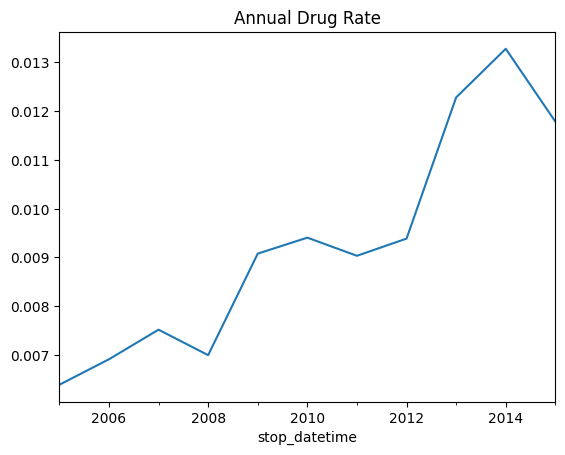

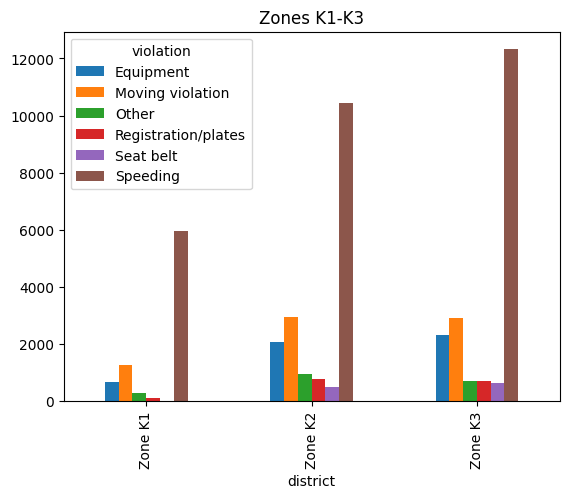

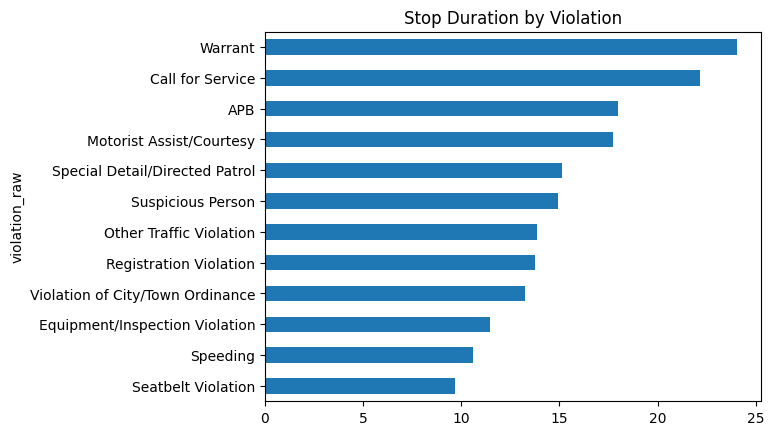



===== DATASET HABERMAN =====

Head Data:
   age  year  nodes  survival_status
0   30    62      3                1
1   30    65      0                1
2   31    59      2                1
3   31    65      4                1
4   33    58     10                1

Statistik:
              age        year       nodes  survival_status
count  305.000000  305.000000  305.000000       305.000000
mean    52.531148   62.849180    4.036066         1.265574
std     10.744024    3.254078    7.199370         0.442364
min     30.000000   58.000000    0.000000         1.000000
25%     44.000000   60.000000    0.000000         1.000000
50%     52.000000   63.000000    1.000000         1.000000
75%     61.000000   66.000000    4.000000         2.000000
max     83.000000   69.000000   52.000000         2.000000

Survival Count:
survival_status
1    224
2     81
Name: count, dtype: int64


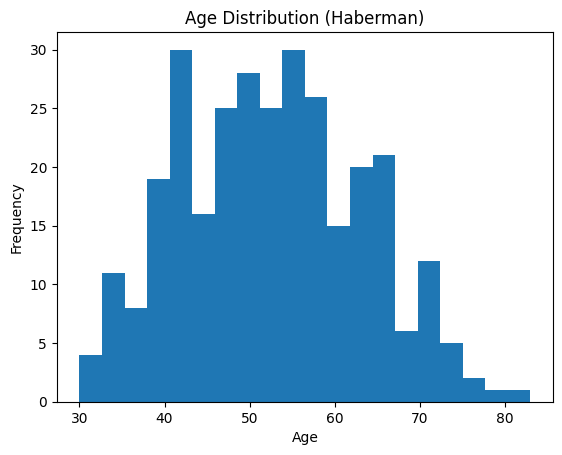

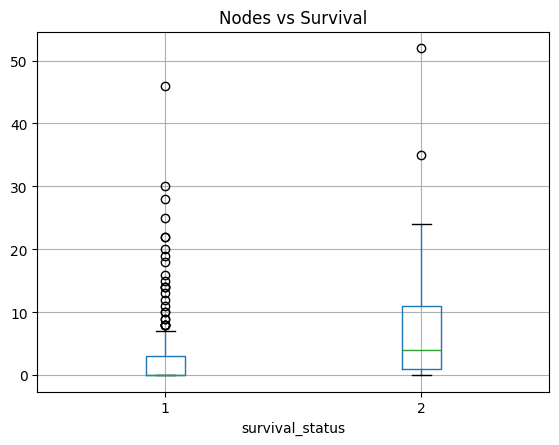


Average Age by Survival:
survival_status
1    52.116071
2    53.679012
Name: age, dtype: float64


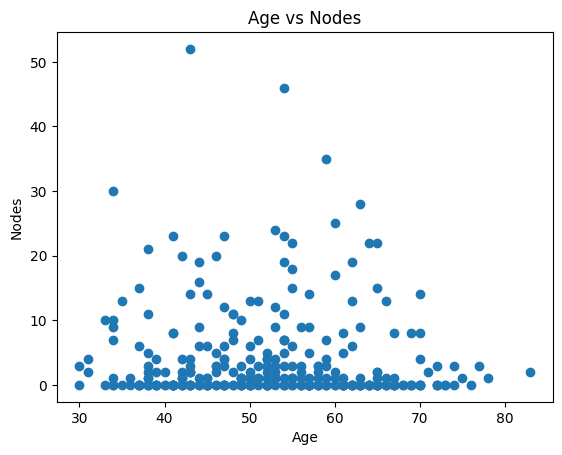

In [19]:
# =========================
# IMPORT LIBRARY
# =========================
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# =========================
# DATASET 1: POLICE
# =========================
# =========================

print("===== DATASET POLICE =====")

ri = pd.read_csv('police.csv')

# Gabung tanggal & waktu
combined = ri['stop_date'].astype(str).str.cat(
    ri['stop_time'].astype(str),
    sep=' '
)

ri['stop_datetime'] = pd.to_datetime(combined, errors='coerce')
ri['is_arrested'] = ri['is_arrested'].astype(bool)
ri.set_index('stop_datetime', inplace=True)

# Arrest rate
print("\nOverall Arrest Rate:")
print(ri['is_arrested'].mean())

# Hourly arrest rate
hourly_arrest_rate = ri.groupby(ri.index.hour)['is_arrested'].mean()

hourly_arrest_rate.plot()
plt.title('Arrest Rate by Hour (Police)')
plt.xlabel('Hour')
plt.ylabel('Rate')
plt.show()

# Drug rate tahunan
annual_drug_rate = ri['drugs_related_stop'].resample('A').mean()
annual_drug_rate.plot()
plt.title('Annual Drug Rate')
plt.show()

# Crosstab
all_zones = pd.crosstab(ri['district'], ri['violation'])
k_zones = all_zones.loc['Zone K1':'Zone K3']

k_zones.plot(kind='bar')
plt.title('Zones K1-K3')
plt.show()

# Stop duration
mapping = {'0-15 Min': 8, '16-30 Min': 23, '30+ Min': 45}
ri['stop_minutes'] = ri['stop_duration'].map(mapping)

stop_length = ri.groupby('violation_raw')['stop_minutes'].mean()
stop_length.sort_values().plot(kind='barh')
plt.title('Stop Duration by Violation')
plt.show()


# =========================
# =========================
# DATASET 2: HABERMAN
# =========================
# =========================

print("\n\n===== DATASET HABERMAN =====")

# Load data
haberman = pd.read_csv('haberman.csv')

# Rename kolom biar jelas
haberman.columns = ['age', 'year', 'nodes', 'survival_status']

# Cek data
print("\nHead Data:")
print(haberman.head())

# =========================
# ANALISIS HABERMAN
# =========================

# Statistik dasar
print("\nStatistik:")
print(haberman.describe())

# Distribusi survival
print("\nSurvival Count:")
print(haberman['survival_status'].value_counts())

# Plot distribusi umur
haberman['age'].plot(kind='hist', bins=20)
plt.title('Age Distribution (Haberman)')
plt.xlabel('Age')
plt.show()

# Plot nodes vs survival
haberman.boxplot(column='nodes', by='survival_status')
plt.title('Nodes vs Survival')
plt.suptitle('')
plt.show()

# Rata-rata umur berdasarkan survival
print("\nAverage Age by Survival:")
print(haberman.groupby('survival_status')['age'].mean())

# Scatter plot
plt.scatter(haberman['age'], haberman['nodes'])
plt.xlabel('Age')
plt.ylabel('Nodes')
plt.title('Age vs Nodes')
plt.show()